In [46]:
from pandas import read_csv,DataFrame
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,ConfusionMatrixDisplay,roc_curve)

import joblib

In [2]:
df = read_csv("data/loan_prediction_dataset.csv")

In [3]:
df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


In [4]:
df.tail()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
1995,63,87580,761,29716,48,Employed,1
1996,67,27368,695,13601,36,Employed,0
1997,69,105436,636,37018,36,Self-Employed,0
1998,24,116136,441,9061,48,Employed,0
1999,20,66403,616,9609,12,Unemployed,0


In [5]:
df.shape

(2000, 7)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                2000 non-null   int64
 1   Income             2000 non-null   int64
 2   Credit_Score       2000 non-null   int64
 3   Loan_Amount        2000 non-null   int64
 4   Loan_Term          2000 non-null   int64
 5   Employment_Status  2000 non-null   str  
 6   Loan_Approved      2000 non-null   int64
dtypes: int64(6), str(1)
memory usage: 109.5 KB


In [7]:
df.describe(include="all")

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000,2000.000000
unique,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,NaN,NaN,NaN,Employed,NaN
freq,NaN,NaN,NaN,NaN,NaN,1260,NaN
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,NaN,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,NaN,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,NaN,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,NaN,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,NaN,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,NaN,0.000000


In [8]:
df.isna().sum()

Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

Employment_Status
Employed         1260
Unemployed        375
Self-Employed     365
Name: count, dtype: int64
-------------------------------------------------------------------------------------
Employment_Status
Employed         63.00
Unemployed       18.75
Self-Employed    18.25
Name: proportion, dtype: float64
-------------------------------------------------------------------------------------
Loan_Approved
0    1658
1     342
Name: count, dtype: int64
-------------------------------------------------------------------------------------
Loan_Approved
0    82.9
1    17.1
Name: proportion, dtype: float64
-------------------------------------------------------------------------------------


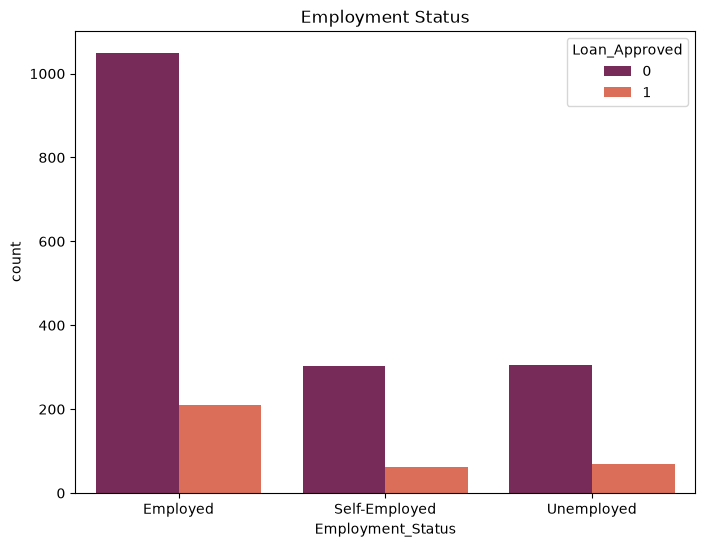

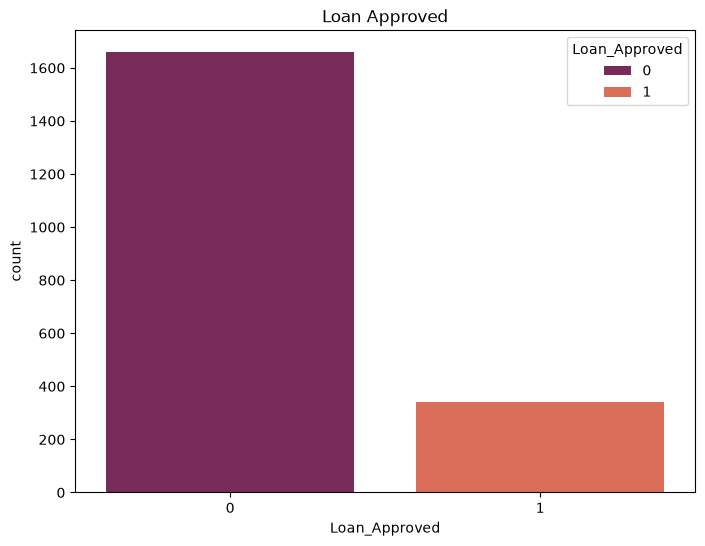

In [12]:
print(df["Employment_Status"].value_counts())
print("-"*85)
print(df["Employment_Status"].value_counts(normalize=True)*100)
print("-"*85)
print(df["Loan_Approved"].value_counts())
print("-"*85)
print(df["Loan_Approved"].value_counts(normalize=True)*100)
print("-"*85)

col_count = {
    "Employment_Status":"Employment Status",
    "Loan_Approved":"Loan Approved"
}

for col,ti in col_count.items():
    plt.figure(figsize=(8,6))
    sns.countplot(df,x=col,hue="Loan_Approved",palette="rocket")
    plt.title(ti)
    plt.savefig(f"images/Countplots/{ti}.png",
            dpi=300,
            bbox_inches="tight")
    plt.show()
    

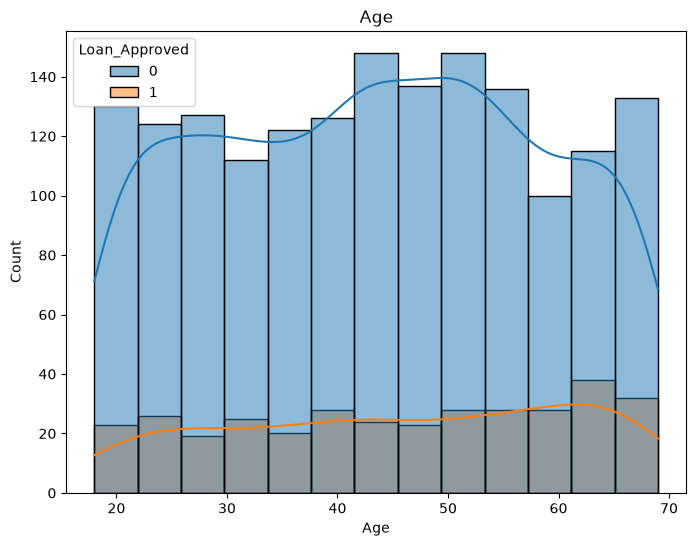

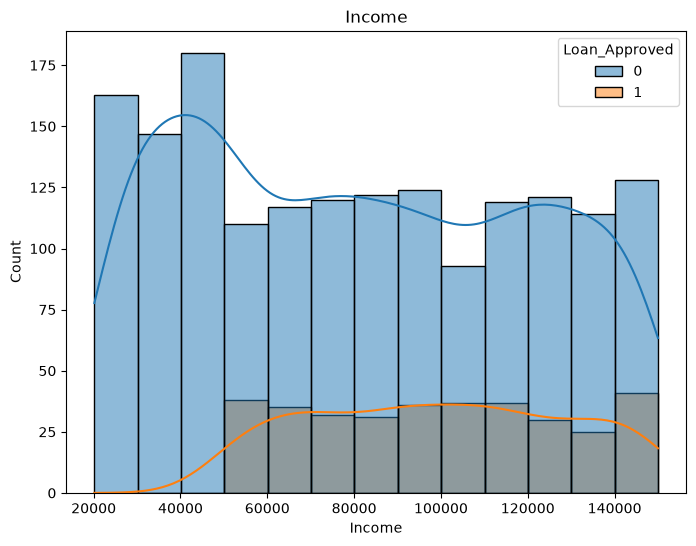

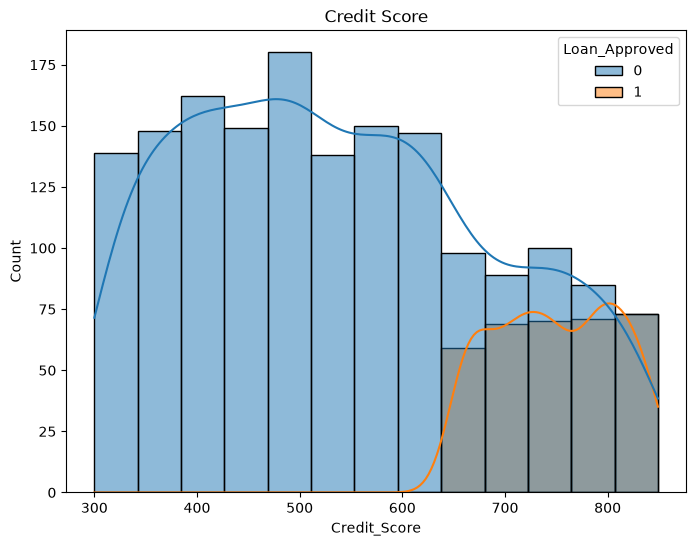

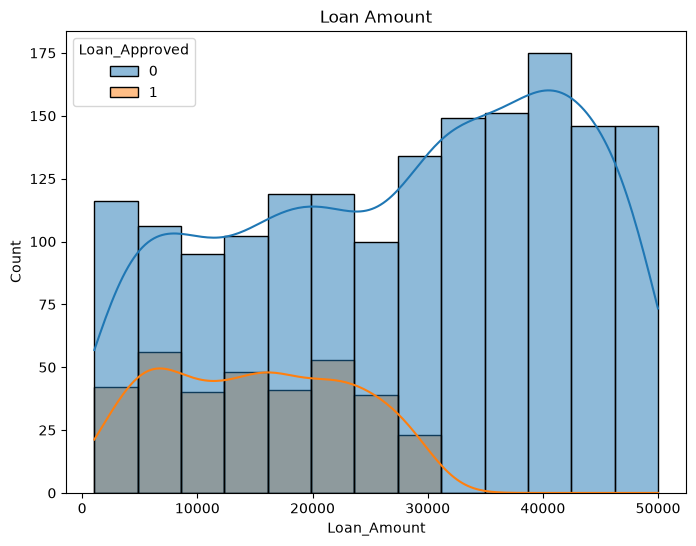

In [13]:
col_hist = {
    "Age":"Age",
    "Income":"Income",
    "Credit_Score":"Credit Score",
    "Loan_Amount":"Loan Amount"
}

for col,ti in col_hist.items():
    plt.figure(figsize=(8,6))
    sns.histplot(df,x=col,hue="Loan_Approved",kde=True)
    plt.title(ti)
    plt.savefig(f"images/Histplots/{ti}.png",
            dpi=300,
            bbox_inches="tight")
    plt.show()
    

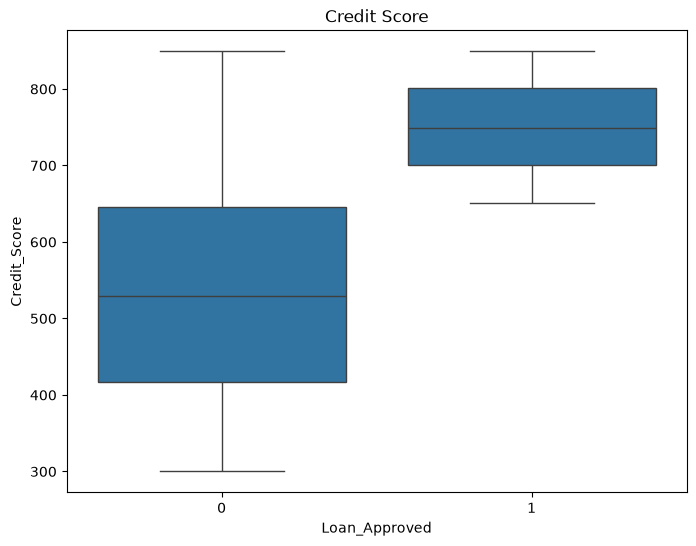

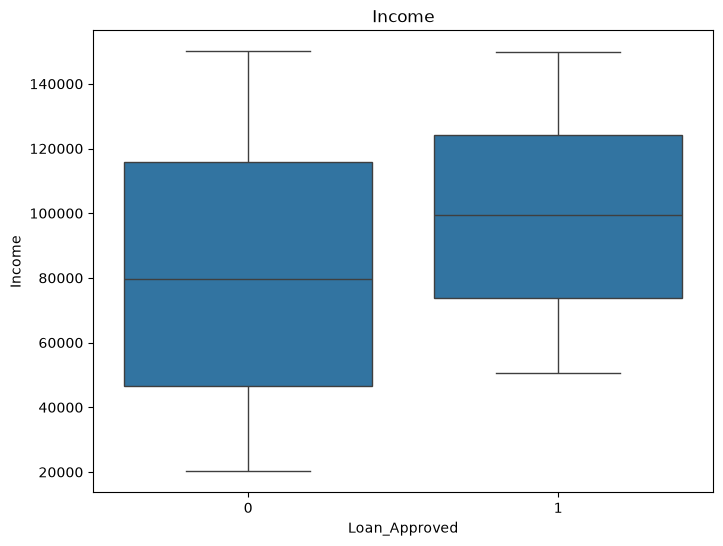

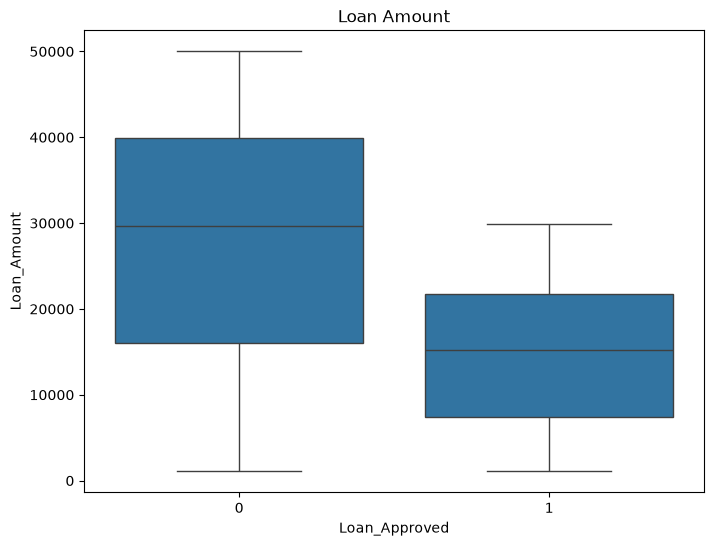

In [14]:
col_box = {
    "Credit_Score":"Credit Score",
    "Income":"Income",
    "Loan_Amount":"Loan Amount"
}

for col,ti in col_box.items():
    plt.figure(figsize=(8,6))
    sns.boxplot(df,x="Loan_Approved",y=col)
    plt.title(ti)
    plt.savefig(f"images/Boxplots/{ti}.png",
            dpi=300,
            bbox_inches="tight")
    plt.show()

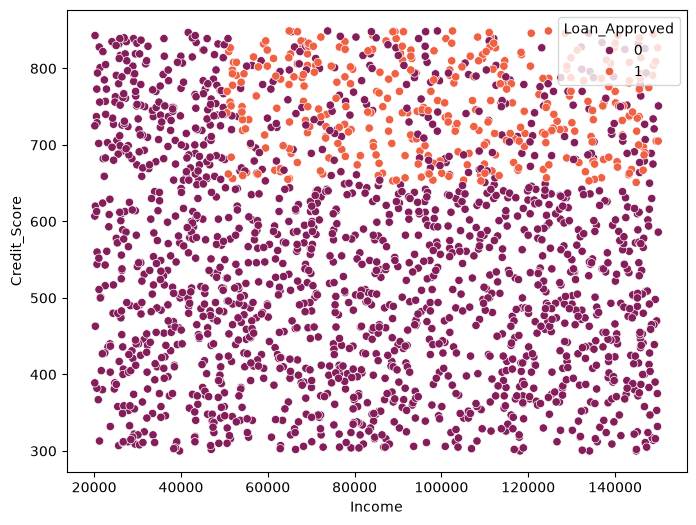

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(df,x="Income",y="Credit_Score",hue="Loan_Approved",palette="rocket")
plt.savefig(f"images/Scatterplots/scatterplot1.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

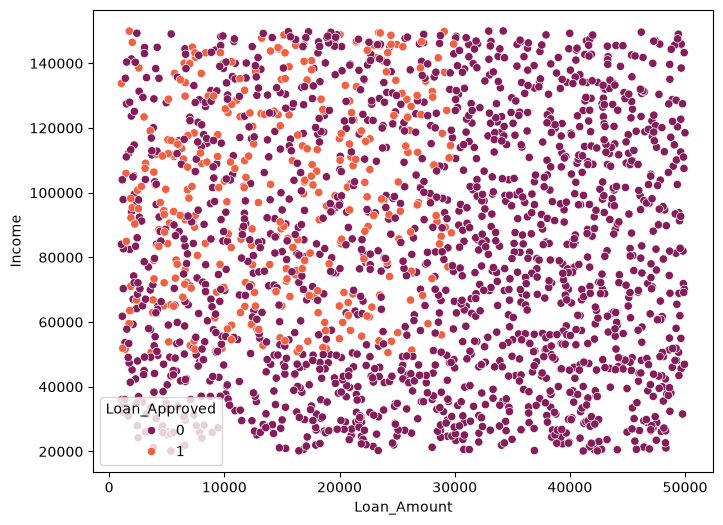

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(df,x="Loan_Amount",y="Income",hue="Loan_Approved",palette="rocket")
plt.savefig(f"images/Scatterplots/scatterplot2.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [18]:
(df.drop("Loan_Approved",axis=1) == 0).sum()

Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
dtype: int64

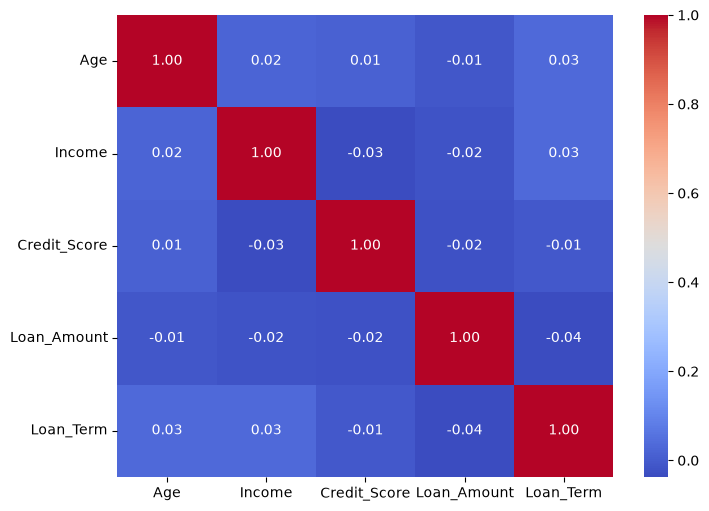

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop("Loan_Approved",axis=1).corr(numeric_only=True),annot=True,fmt=".2f",cmap="coolwarm")
plt.savefig(f"images/Heatmap/heatmap.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [20]:
df["Employment_Status"] = df["Employment_Status"].map({
    "Employed":0,
    "Self-Employed":1,
    "Unemployed":2
})

In [21]:
X = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)

In [22]:
numeric_col = ["Age","Income","Credit_Score","Loan_Amount","Loan_Term"]
cat_col = ["Employment_Status"]

In [23]:
preprocessor = ColumnTransformer([
    ("num","passthrough",numeric_col),
    ("cat",OneHotEncoder(handle_unknown="ignore"),cat_col)
])

XGBoots

In [24]:
pipe_xg = Pipeline([
    ("preprocessor",preprocessor),
    ("model",XGBClassifier(random_state=42,eval_metric="logloss"))
])

param_xg = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

In [25]:
grid_xg = RandomizedSearchCV(pipe_xg,param_xg,n_iter=30,cv=5,scoring="roc_auc",n_jobs=-1,verbose=1,random_state=42)

In [26]:
grid_xg.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be

In [27]:
print("-"*40, " XGBoots " , "-"*40)
print("Best Params : ",grid_xg.best_params_)
print("Best Score : ",grid_xg.best_score_)

----------------------------------------  XGBoots  ----------------------------------------
Best Params :  {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.2, 'model__gamma': 0.1, 'model__colsample_bytree': 0.7}
Best Score :  0.999782637825178


Gradient Boosting

In [28]:
pipe_gb = Pipeline([
    ("preprocessor",preprocessor),
    ("model",GradientBoostingClassifier())
])

param_gb = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

In [29]:
grid_gb = RandomizedSearchCV(pipe_gb,param_gb,n_iter=30,cv=5,scoring="roc_auc",verbose=1,n_jobs=-1,random_state=42)

In [30]:
grid_gb.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` ca

In [31]:
print("-"*40, " GradientBoosting " , "-"*40)
print("Best Params : ",grid_gb.best_params_)
print("Best Score : ",grid_gb.best_score_)

----------------------------------------  GradientBoosting  ----------------------------------------
Best Params :  {'model__subsample': 0.9, 'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 3, 'model__learning_rate': 0.01}
Best Score :  0.9999844913151363


LightGBM

In [33]:
pipe_lgbm = Pipeline([
    ("preprocessor",preprocessor),
    ("model",LGBMClassifier(random_state=42,verbosity=-1,n_jobs=1))
])

param_lgbm = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [-1, 3, 5, 7, 10],
    "model__num_leaves": [15, 31, 50, 70],
    "model__min_child_samples": [10, 20, 30, 50],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [34]:
grid_lgbm = RandomizedSearchCV(pipe_lgbm,param_lgbm,n_iter=30,cv=5,scoring="roc_auc",verbose=1,n_jobs=1,random_state=42)

In [35]:
grid_lgbm.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [-1, 3, ...], 'model__min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refi

In [36]:
print("-"*40, " LightGBM " , "-"*40)
print("Best Params : ",grid_lgbm.best_params_)
print("Best Score : ",grid_lgbm.best_score_)

----------------------------------------  LightGBM  ----------------------------------------
Best Params :  {'model__subsample': 1.0, 'model__num_leaves': 50, 'model__n_estimators': 300, 'model__min_child_samples': 20, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}
Best Score :  0.9999214942287515


CatBoost

In [37]:
pipe_cat = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostClassifier(verbose=0,random_state=42))
])

param_cat = {
    "model__iterations": [100, 200, 300, 500],
    "model__depth": [4, 5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__l2_leaf_reg": [1, 3, 5, 7, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

In [38]:
grid_cat = RandomizedSearchCV(pipe_cat,param_cat,n_iter=30,cv=5,scoring="roc_auc",verbose=1,n_jobs=-1,random_state=42)

In [39]:
grid_cat.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__depth': [4, 5, ...], 'model__iterations': [100, 200, ...], 'model__l2_leaf_reg': [1, 3, ...], 'model__learning_rate': [0.01, 0.05, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to 

In [40]:
print("-"*40, " CatBoost " , "-"*40)
print("Best Params : ",grid_cat.best_params_)
print("Best Score : ",grid_cat.best_score_)

----------------------------------------  CatBoost  ----------------------------------------
Best Params :  {'model__subsample': 0.9, 'model__learning_rate': 0.1, 'model__l2_leaf_reg': 3, 'model__iterations': 300, 'model__depth': 8}
Best Score :  1.0


In [41]:
Models = {
    "XGBoost":grid_xg.best_estimator_,
    "LightGBM":grid_lgbm.best_estimator_,
    "GradientBoosting":grid_gb.best_estimator_,
    "CatBoost":grid_cat.best_estimator_
}

In [42]:
results = []

for name, model in Models.items():

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred)*100,
        "Precision": precision_score(y_test, y_pred)*100,
        "Recall": recall_score(y_test, y_pred)*100,
        "F1": f1_score(y_test, y_pred)*100,
        "ROC-AUC": roc_auc_score(y_test, y_prob)*100
    })

In [43]:
res_df = DataFrame(results,index=["",'','',''])
res_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
,XGBoost,100.0,100.0,100.0,100.0,100.0
,LightGBM,100.0,100.0,100.0,100.0,100.0
,GradientBoosting,100.0,100.0,100.0,100.0,100.0
,CatBoost,100.0,100.0,100.0,100.0,100.0


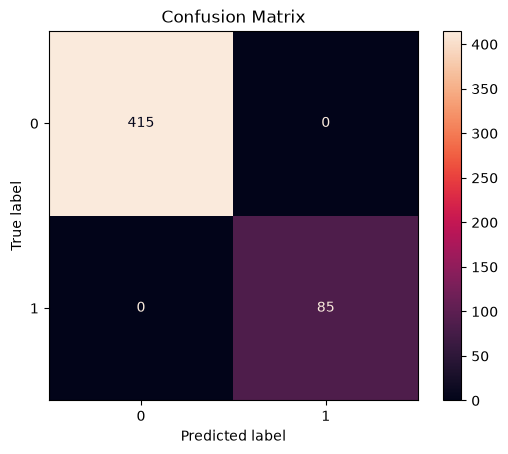

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="rocket")
plt.title("Confusion Matrix")
plt.savefig(f"images/ConfusionMatrix/CM.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

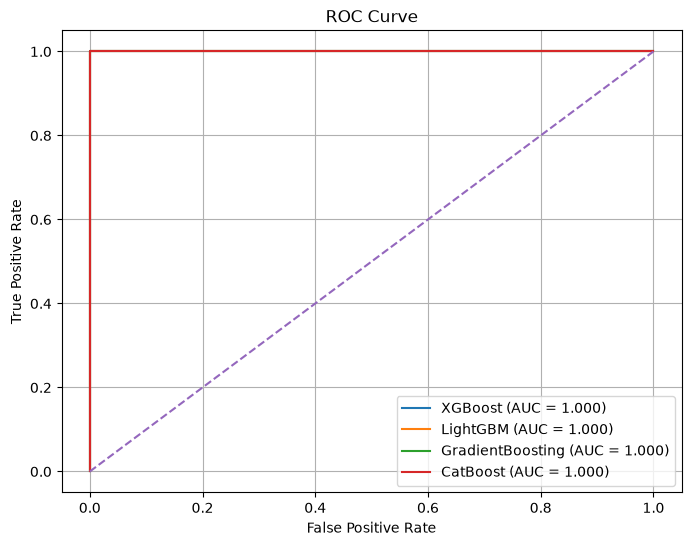

In [45]:
plt.figure(figsize=(8, 6))

for name, model in Models.items():

    y_prob = model.predict_proba(x_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid()
plt.savefig(f"images/ROC_curve/ModelsRateAUC.png",
        dpi=300,
        bbox_inches="tight")

plt.show()

In [47]:
joblib.dump(grid_xg.best_estimator_,"models/XGBoost_Model.joblib")
joblib.dump(grid_lgbm.best_estimator_,"models/LightGBM_Model.joblib")
joblib.dump(grid_gb.best_estimator_,"models/GradientBoosting_Model.joblib")
joblib.dump(grid_cat.best_estimator_,"models/CatBoost_Model.joblib")
print("Models Saved")

Models Saved
